# Data Analytics for Digital Health – Task 4 
**Project:** Analysis of Hospitalized Patients  
**Task:** Classification Analysis 

**Dataset:** patient_profiles_with_labels.csv

## Dependencies

In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# SHAP
import shap

# Settings
sns.set(style="whitegrid")
np.random.seed(42)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\python_ins\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Divya Shah\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1077, in launch_instance
    app.start()
  File "c:\python_ins\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_loop.start()
  File "C:\Users\Divya Shah\AppData\Roaming\

AttributeError: _ARRAY_API not found

c:\python_ins\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Dataset Loading and Overview

In [2]:
df = pd.read_csv('./data/patient_profiles_with_labels.csv')

In [3]:
# Adding this cell to see all columns of data at once, just as a sanity check..

# Assuming you already have a DataFrame called df
# Temporarily set the option to show all columns for this operation
pd.set_option('display.max_columns', None)
df.head(2)

,subject_id,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,mitral_regurgitation,coronary_artery_disease,atrial_fibrillation,severe_stenosis,pulmonary_hypertension,wall_motion_abnormality,st_elevation,lbbb,pleural_effusion,pulmonary_edema,pericardial_effusion,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y,ischemic_disease
0,10000980,75.0,98.1,200.0,65.0,26.0,100.0,0.0,1,0.0,3.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,217.0,0.398,4.5,163.0,2.3,0.0,0.679,1.0,7.0,0.0,1
1,10002013,0.0,99.4,157.0,118.0,24.0,96.0,0.0,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49.0,0.347,3.6,395.0,1.0,0.5,1.000,0.0,2.0,0.0,1


### Dataset Description
Each row represents a **patient-level profile** derived from multiple hospital admissions.
The target variable `ischemic_disease` is a binary label defined as:

- **1:** At least one ischemic ICD code (I20–I25)
- **0:** All other cardiovascular diagnoses

## Feature / Target Definition

In [4]:
X = df.drop(columns=["subject_id", "ischemic_disease"])
y = df["ischemic_disease"]

- All features are numeric (continuous, binary, counts, or ratios)
- No categorical encoding is required

## Train–Test Split (Stratified)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Class Distribution Analysis

Before training supervised models, we analyze the distribution of the target variable
to assess potential class imbalance, which may bias standard accuracy metrics.

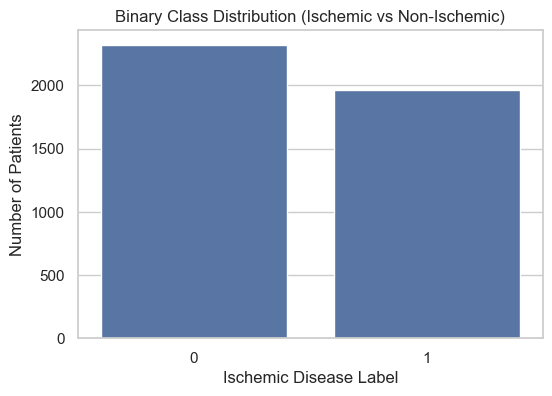

ischemic_disease
0    0.541152
1    0.458848
Name: proportion, dtype: float64

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Binary Class Distribution (Ischemic vs Non-Ischemic)")
plt.xlabel("Ischemic Disease Label")
plt.ylabel("Number of Patients")
plt.show()

y.value_counts(normalize=True)

## 4. Data Preprocessing

### Preprocessing Strategy
- **Missing values:** Median imputation
- **Scaling:** Standardization (required for Logistic Regression)
- **Class imbalance:** Handled via `class_weight="balanced"`

In [7]:
preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

## 5. Correlation Analysis

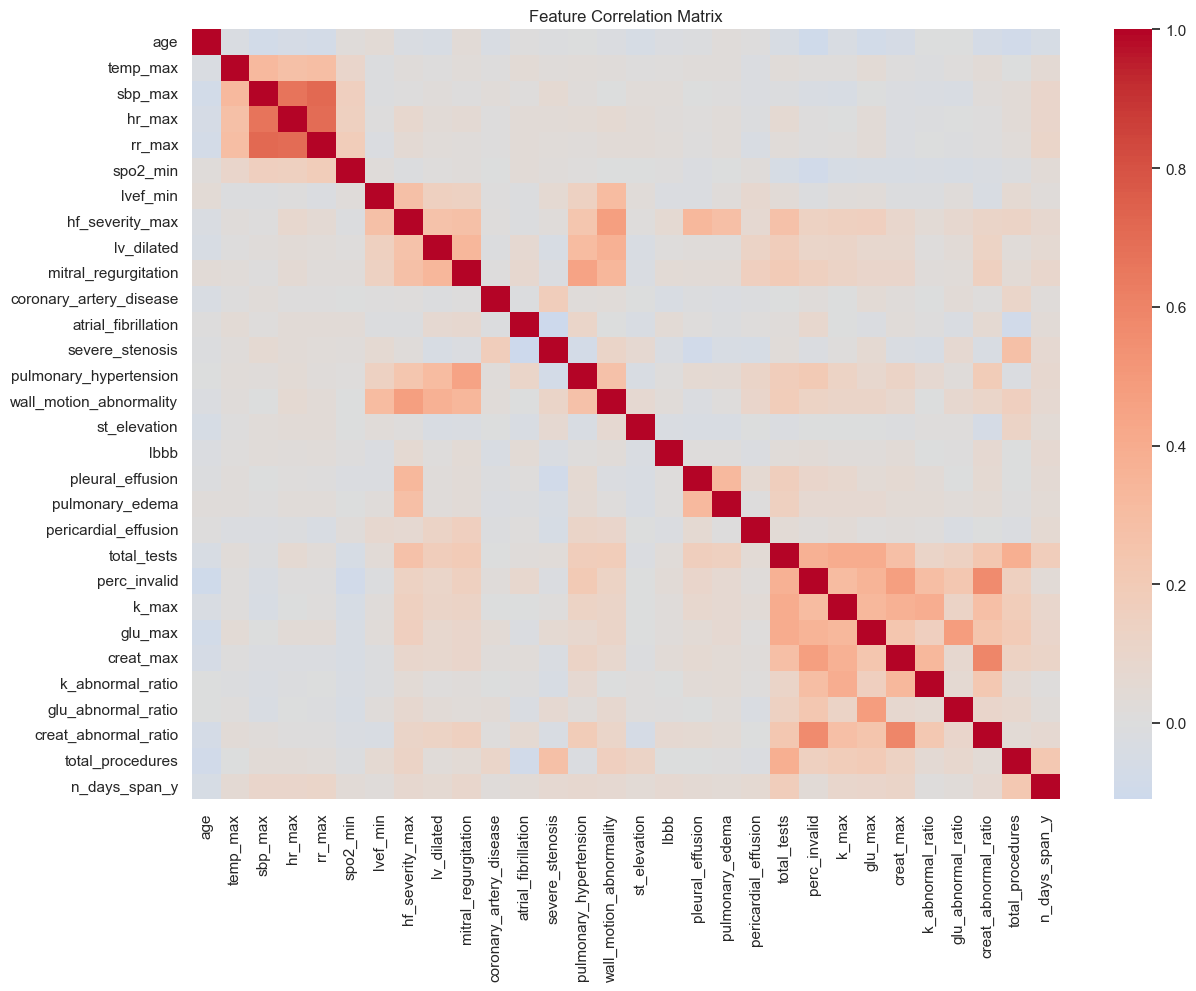

In [8]:
plt.figure(figsize=(14,10))
sns.heatmap(X.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [9]:
# Removing very highly correlated features

# Absolute correlation matrix
corr_matrix = X.corr().abs()

# Upper triangle of the correlation matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Threshold for "very bad" correlation
CORR_THRESHOLD = 0.85

# features to drop
to_drop = [
    column for column in upper.columns
    if any(upper[column] >= CORR_THRESHOLD)
]

print(f"Number of features before removal: {X.shape[1]}")
print(f"Highly correlated features removed (|corr| >= {CORR_THRESHOLD}):")
print(to_drop)

# Dropping features
X_reduced = X.drop(columns=to_drop)

print(f"Number of features after removal: {X_reduced.shape[1]}")

Number of features before removal: 30
Highly correlated features removed (|corr| >= 0.85):
[]
Number of features after removal: 30


### -> Correlated features with correlation less than 85% were retained. 
### -> Regularized and tree-based models mitigate multicollinearity effects without explicit feature removal.

## Detailed Explanation:  
### Feature Removal Strategy

Variables showing very high and clinically redundant correlation (near‑duplicate information) can be safely removed to reduce dimensionality and improve interpretability.  
After this minimal pruning, the remaining correlated features were intentionally retained.

### Justification for Retaining Correlated Features

Tree‑based models such as Random Forest and Gradient Boosting are inherently robust to multicollinearity because:
- They perform feature selection implicitly through split optimization
- Correlated variables compete during tree construction without destabilizing the model
- Feature importance and SHAP values still provide meaningful interpretability

Therefore, after removing only severely redundant features, no aggressive feature elimination was applied. This choice preserves clinically meaningful information while maintaining model stability and performance.

## 6. Model Training
### 6.1 Logistic Regression (Baseline)

In [10]:
log_reg = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Ca

## 6.2 Random Forest

In [11]:
rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ))
])

rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

## 6.3 Gradient Boosting

In [12]:
gb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

## ROC Curve Comparison

Receiver Operating Characteristic (ROC) curves are used to compare the discrimination
ability of different classifiers across all decision thresholds.

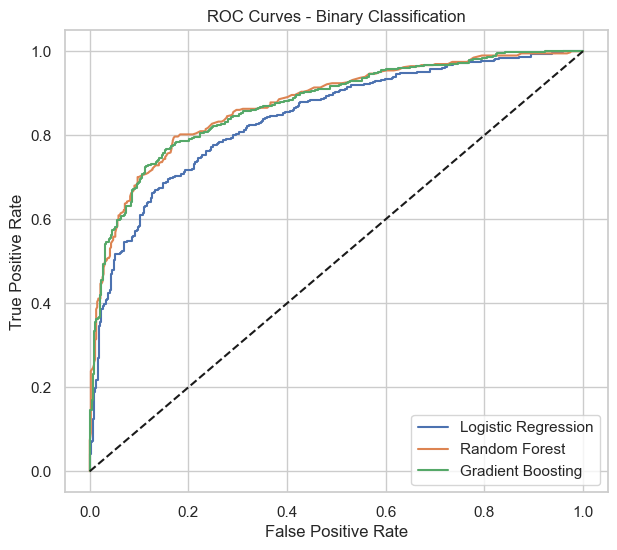

In [13]:
plt.figure(figsize=(7,6))

for name, model in {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "Gradient Boosting": gb
}.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Binary Classification")
plt.legend()
plt.show()

## Precision–Recall Curve Analysis

Precision–Recall curves are particularly informative for imbalanced datasets,
highlighting trade-offs between false positives and false negatives.

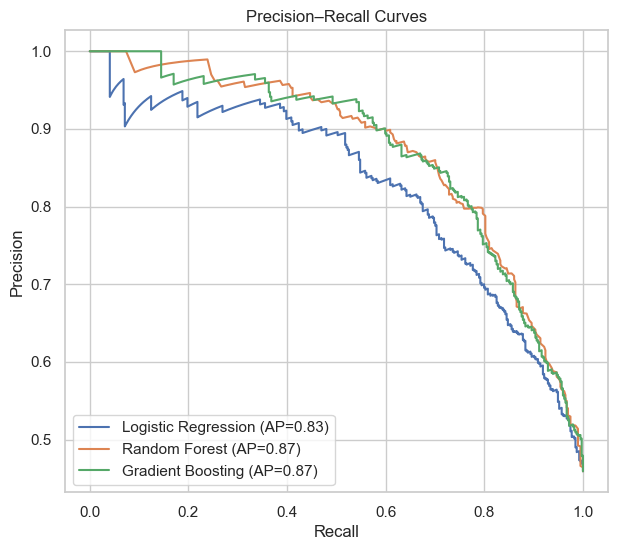

In [14]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7,6))

for name, model in {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "Gradient Boosting": gb
}.items():
    y_prob = model.predict_proba(X_test)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.show()

## Learning Curve Analysis

Learning curves help identify overfitting or underfitting by comparing training
and validation performance as a function of training set size.

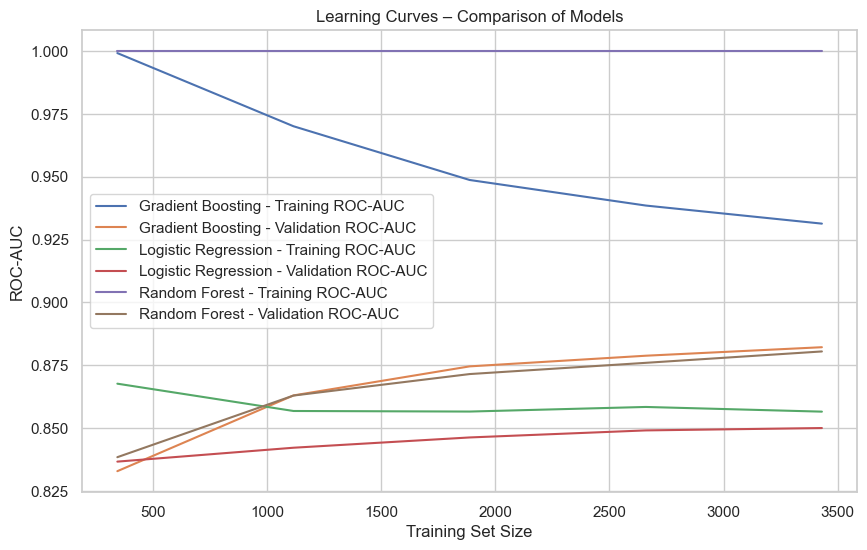

In [15]:
models = {
    "Gradient Boosting": gb,
    "Logistic Regression": log_reg, 
    "Random Forest": rf
    }

plt.figure(figsize=(10,6))

for model_name, model in models.items():
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y,
        cv=5,
        scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )
    
    plt.plot(train_sizes, train_scores.mean(axis=1), label=f"{model_name} - Training ROC-AUC")
    plt.plot(train_sizes, test_scores.mean(axis=1), label=f"{model_name} - Validation ROC-AUC")

plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curves – Comparison of Models")
plt.legend()
plt.show()


## 7. Model Evaluation

In [16]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    results = {}
    for split, Xs, ys in [("Train", X_tr, y_tr), ("Test", X_te, y_te)]:
        y_pred = model.predict(Xs)
        y_prob = model.predict_proba(Xs)[:,1]
        results[split] = {
            "Accuracy": accuracy_score(ys, y_pred),
            "Balanced Accuracy": balanced_accuracy_score(ys, y_pred),
            "Precision": precision_score(ys, y_pred),
            "Recall": recall_score(ys, y_pred),
            "F1": f1_score(ys, y_pred),
            "ROC-AUC": roc_auc_score(ys, y_prob)
        }
    return pd.DataFrame(results)

In [17]:
for name, model in {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "Gradient Boosting": gb
}.items():
    print(f"\n{name}")
    display(evaluate_model(model, X_train, y_train, X_test, y_test))


Logistic Regression


,Train,Test
Accuracy,0.783445,0.763403
Balanced Accuracy,0.780243,0.759425
Precision,0.776447,0.758808
Recall,0.741423,0.710660
F1,0.758531,0.733945
ROC-AUC,0.858644,0.839948



Random Forest


,Train,Test
Accuracy,1.0,0.808858
Balanced Accuracy,1.0,0.800685
Precision,1.0,0.857143
Recall,1.0,0.700508
F1,1.0,0.770950
ROC-AUC,1.0,0.874869



Gradient Boosting


,Train,Test
Accuracy,0.855727,0.808858
Balanced Accuracy,0.849632,0.801834
Precision,0.895818,0.844311
Recall,0.775731,0.715736
F1,0.831461,0.774725
ROC-AUC,0.932596,0.873053


## Feature Importance Comparison

Tree-based models provide intrinsic measures of feature importance, offering
insight into the clinical variables most relevant for ischemic disease prediction.

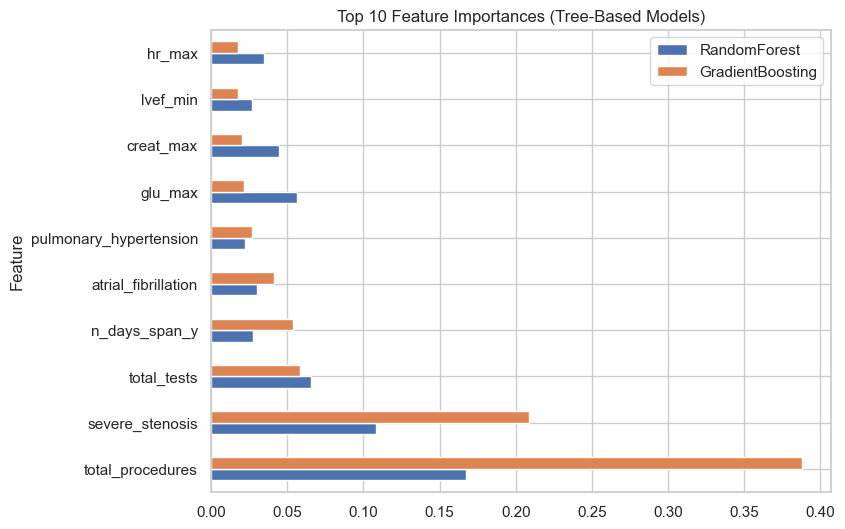

In [18]:
importances_rf = rf.named_steps["model"].feature_importances_
importances_gb = gb.named_steps["model"].feature_importances_

fi = pd.DataFrame({
    "Feature": X.columns,
    "RandomForest": importances_rf,
    "GradientBoosting": importances_gb
}).set_index("Feature")

fi.sort_values("GradientBoosting", ascending=False).head(10).plot(
    kind="barh", figsize=(8,6)
)
plt.title("Top 10 Feature Importances (Tree-Based Models)")
plt.show()

## Confusion Matrix (Best Model)

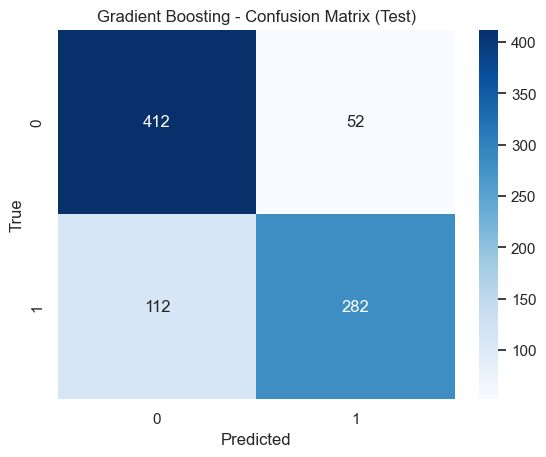

In [19]:
best_model = gb
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Gradient Boosting - Confusion Matrix (Test)")
plt.show()

# False Negatives (Ischemic Patients Predicted as Non-Ischemic)

False negatives represent patients with ischemic heart disease who are incorrectly classified as non-ischemic. From a clinical perspective, this is the most critical error, as it may lead to:

- **Delayed diagnosis** or missed identification of ischemic conditions
- **Under-treatment** or lack of timely interventions (e.g., revascularization, antiplatelet therapy)
- **Increased risk of adverse cardiovascular outcomes**

In our analysis, false negatives tend to show:

- **Less extreme laboratory abnormalities**
- **Lower procedure counts**

This suggests that milder or atypical ischemic presentations are harder to distinguish from non-ischemic conditions.

## 9. SHAP Interpretability (Gradient Boosting)
### SHAP values are used to explain feature contributions to ischemic disease prediction.

C:\Users\Divya Shah\AppData\Local\Temp\ipykernel_13676\555260007.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train, plot_type="bar")


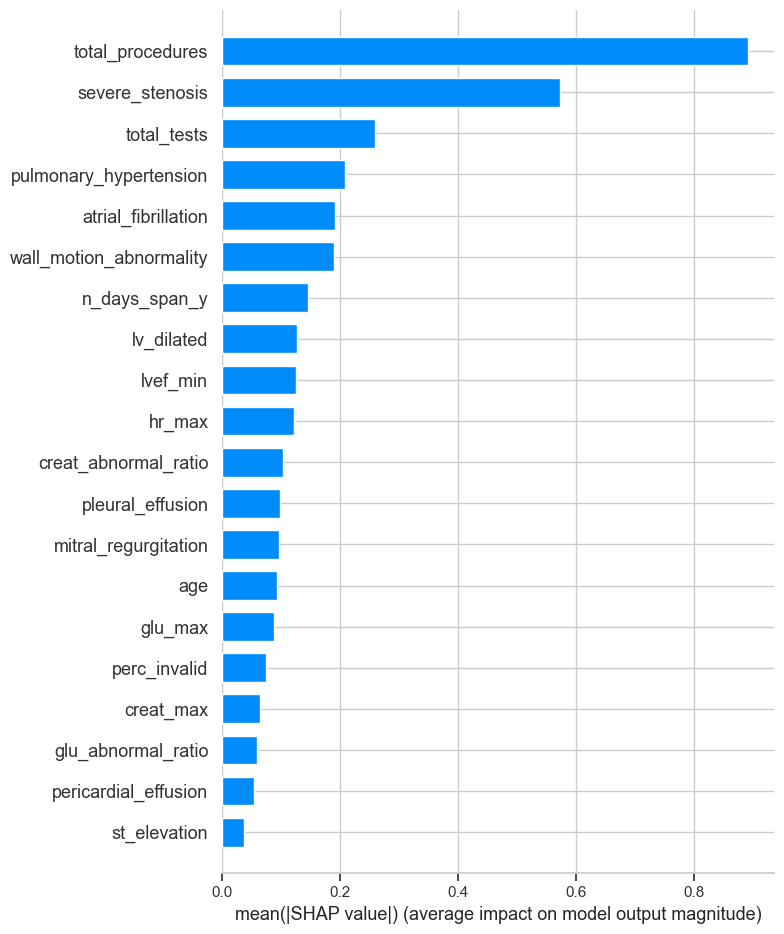

In [20]:
X_train_imp = best_model.named_steps["imputer"].transform(X_train)
explainer = shap.Explainer(best_model.named_steps["model"], X_train_imp)
shap_values = explainer(X_train_imp)

shap.summary_plot(shap_values, X_train, plot_type="bar")

## SHAP Beeswarm Plot

The SHAP beeswarm plot shows both the importance and direction of each feature’s
impact across individual patients.

C:\Users\Divya Shah\AppData\Local\Temp\ipykernel_13676\3022310071.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train)


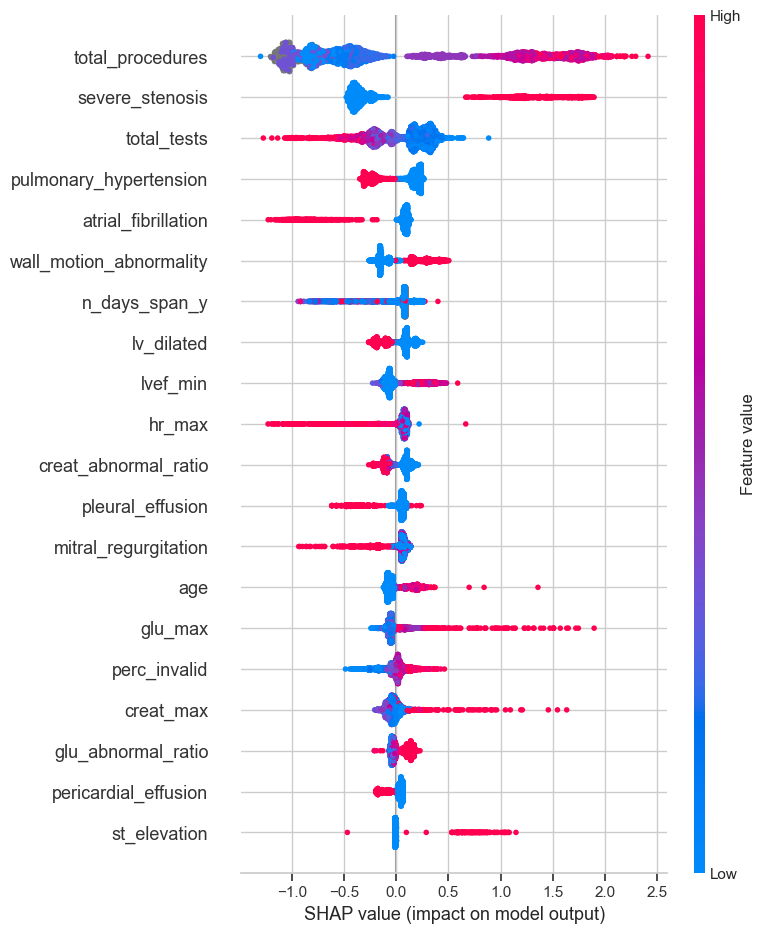

In [21]:
shap.summary_plot(shap_values, X_train)

## Error Analysis

We analyze misclassified patients to understand systematic model errors and
potential clinical implications.

In [22]:
test_results = X_test.copy()
test_results["true"] = y_test.values
test_results["pred"] = y_pred

false_pos = test_results[(test_results.true == 0) & (test_results.pred == 1)]
false_neg = test_results[(test_results.true == 1) & (test_results.pred == 0)]

false_pos.describe()

,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,mitral_regurgitation,coronary_artery_disease,atrial_fibrillation,severe_stenosis,pulmonary_hypertension,wall_motion_abnormality,st_elevation,lbbb,pleural_effusion,pulmonary_edema,pericardial_effusion,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y,true,pred
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,50.000000,50.000000,52.0,52.0
mean,24.365385,54.901923,58.480769,37.730769,8.461538,72.730769,19.076923,0.788462,0.346154,0.807692,0.057692,0.057692,0.288462,0.307692,0.538462,0.019231,0.038462,0.057692,0.019231,0.230769,218.942308,0.342481,4.726923,221.750000,2.138462,0.046038,0.726865,0.404558,4.240000,1.740000,0.0,1.0
std,35.480472,48.035512,64.779109,38.044925,9.483653,42.440323,24.905977,0.956639,0.480384,1.155353,0.235435,0.235435,0.457467,0.466041,0.503382,0.138675,0.194184,0.235435,0.138675,0.425436,188.484816,0.141208,0.490344,136.617094,2.373890,0.102240,0.303464,0.446975,2.966204,3.128604,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000,0.024000,3.700000,92.000000,0.600000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,1.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,69.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,77.000000,0.246750,4.300000,119.000000,1.000000,0.000000,0.500000,0.000000,2.000000,0.000000,0.0,1.0
50%,0.000000,93.500000,0.000000,42.500000,0.000000,97.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,145.000000,0.346500,4.700000,189.000000,1.250000,0.000000,0.871000,0.160500,3.000000,0.500000,0.0,1.0
75%,52.250000,98.500000,123.000000,74.000000,18.000000,98.000000,40.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,313.000000,0.457500,5.100000,265.000000,1.875000,0.043250,1.000000,0.955750,6.000000,2.000000,0.0,1.0
max,94.000000,108.100000,159.000000,105.000000,32.000000,100.000000,71.000000,3.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,825.000000,0.602000,5.900000,723.000000,12.200000,0.500000,1.000000,1.000000,12.000000,18.000000,0.0,1.0


In [23]:
false_neg.describe()

,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,mitral_regurgitation,coronary_artery_disease,atrial_fibrillation,severe_stenosis,pulmonary_hypertension,wall_motion_abnormality,st_elevation,lbbb,pleural_effusion,pulmonary_edema,pericardial_effusion,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y,true,pred
count,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,88.000000,88.000000,112.0,112.0
mean,13.883929,59.267857,71.946429,38.803571,9.544643,82.285714,10.080357,0.678571,0.464286,1.142857,0.017857,0.107143,0.026786,0.410714,0.446429,0.035714,0.044643,0.062500,0.035714,0.169643,203.125000,0.337143,4.585714,166.026786,1.483036,0.040661,0.624384,0.401277,3.272727,7.227273,1.0,0.0
std,28.438252,56.359097,68.826435,42.259993,10.048431,35.042684,19.036304,1.171849,0.500964,1.236510,0.133027,0.310685,0.162182,0.494175,0.499356,0.186411,0.207447,0.243149,0.186411,0.377006,206.118707,0.119655,0.578886,76.532800,1.000890,0.085932,0.349780,0.428311,2.576317,45.159673,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.080000,3.500000,80.000000,0.400000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,94.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,74.750000,0.248750,4.200000,118.000000,0.900000,0.000000,0.333000,0.000000,2.000000,0.000000,1.0,0.0
50%,0.000000,96.050000,106.000000,0.000000,0.000000,97.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,133.500000,0.344500,4.500000,147.500000,1.300000,0.000000,0.667000,0.309500,3.000000,0.000000,1.0,0.0
75%,0.000000,98.000000,136.000000,76.250000,18.500000,98.250000,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,252.750000,0.422250,4.900000,184.000000,1.600000,0.027000,1.000000,1.000000,4.000000,0.250000,1.0,0.0
max,91.000000,279.000000,178.000000,127.000000,30.000000,100.000000,66.000000,5.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1104.000000,0.569000,6.900000,508.000000,7.700000,0.429000,1.000000,1.000000,21.000000,406.000000,1.0,0.0


# Insights from Error Analysis

### a. False Negatives Represent Clinically Subtle Ischemic Presentations

False negatives (ischemic patients classified as non‑ischemic) show less pronounced clinical severity compared to correctly classified ischemic cases:

- **Lower laboratory abnormality ratios:**
  - Mean glucose abnormality ratio ≈ 0.62
  - Mean potassium abnormality ratio ≈ 0.04
- **Lower procedure burden:**
  - Mean total procedures ≈ 3.27
- **Often normal or mildly reduced cardiac function:**
  - Median LVEF = 0
- **Wall motion abnormalities present in less than half of cases**

These patients likely correspond to early‑stage, atypical, or clinically compensated ischemic disease, where laboratory and procedural signals are not yet strongly abnormal.

#### Clinical Implication:
This suggests the model relies heavily on severity markers and may miss ischemic disease when it presents without clear physiological deterioration.

--

### b. False Positives Are Driven by High Clinical Complexity Rather Than True Ischemia

False positives (non‑ischemic patients predicted as ischemic) display high overall clinical burden, despite lacking ischemic diagnoses:

- **Very high testing intensity:**
  - Mean total laboratory tests ≈ 219
- **High glucose abnormality ratio:**
  - Mean ≈ 0.73
- **Elevated comorbidity indicators:**
  - Heart failure severity (mean ≈ 0.79)
  - Mitral regurgitation frequently present
  - Pulmonary hypertension and wall motion abnormalities common

These profiles resemble severe non‑ischemic cardiac conditions, such as advanced heart failure or valvular disease, which clinically overlap with ischemic presentations.

#### Clinical Implication:
The model captures global cardiovascular severity, which increases sensitivity but leads to false alarms in complex non‑ischemic patients.

--

### c. Model Bias Toward Severity Signals

Comparing both error types reveals a consistent pattern:

- **False negatives** → milder, fewer abnormalities, fewer procedures
- **False positives** → severe disease burden, multiple abnormalities

This indicates the classifier prioritizes severity‑driven features (laboratory abnormalities, procedure counts, structural heart markers) over purely diagnostic indicators.

#### Interpretation:
The model is better at identifying “sick” patients than distinguishing ischemic etiology from other severe cardiovascular diseases.

--

### d. Implications for Threshold Selection and Clinical Use

From a clinical deployment perspective:

- Lowering the classification threshold could reduce false negatives, improving ischemic disease detection.
- This would likely increase false positives, but at the cost of additional (often acceptable) diagnostic testing.
  
This trade‑off is consistent with screening‑oriented clinical decision support, where missing ischemic disease is riskier than over‑investigation.

--

### e. Methodological Insight for Feature Engineering

The observed errors suggest potential future improvements:

- Introduce **temporal patterns** (e.g., trends in glucose or troponin‑like proxies)
- Weight **ischemia‑specific ECG features** more strongly
- Separate **severity indicators** from **etiology indicators** in feature design

---

## OPTIONAL TASK: MULTICLASS CLASSIFICATION
### 10. Multiclass Label Definition

We define four clinically meaningful cardiac disease classes based on ICD‑10 diagnosis codes:

0 – **Ischemic heart disease**  
Includes angina pectoris, acute myocardial infarction, subsequent infarction, other acute ischemic syndromes, and chronic ischemic heart disease.

1 – **Arrhythmias and conduction disorders**  
Includes atrioventricular and bundle‑branch blocks, other conduction disorders, supraventricular and ventricular arrhythmias, atrial fibrillation and flutter, paroxysmal tachycardia, and cardiac arrest.

2 – **Valvular and pump failure disorders**  
Includes non‑rheumatic mitral, aortic, and tricuspid valve disorders, cardiomyopathies, and heart failure.

4 – **Inflammatory and structural heart disease**  
Includes acute pericarditis, other pericardial diseases, acute and subacute endocarditis, myocarditis, and related structural cardiac abnormalities.

In [24]:
df = pd.read_csv('./data/patient_profiles_with_multiclass_labels.csv')

In [25]:
# Adding this cell to see all columns of data at once, just as a sanity check..

# Assuming you already have a DataFrame called df
# Temporarily set the option to show all columns for this operation
pd.set_option('display.max_columns', None)
df.head(2)

,subject_id,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,mitral_regurgitation,coronary_artery_disease,atrial_fibrillation,severe_stenosis,pulmonary_hypertension,wall_motion_abnormality,st_elevation,lbbb,pleural_effusion,pulmonary_edema,pericardial_effusion,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y,cardiac_class
0,10000980,75.0,98.1,200.0,65.0,26.0,100.0,0.0,1,0.0,3.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,217.0,0.398,4.5,163.0,2.3,0.0,0.679,1.0,7.0,0.0,1
1,10002013,0.0,99.4,157.0,118.0,24.0,96.0,0.0,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49.0,0.347,3.6,395.0,1.0,0.5,1.000,0.0,2.0,0.0,1


In [26]:
y_multi = df["cardiac_class"]

## 11. Data Splitting and Preprocessing

In [27]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.2, stratify=y_multi, random_state=42
)

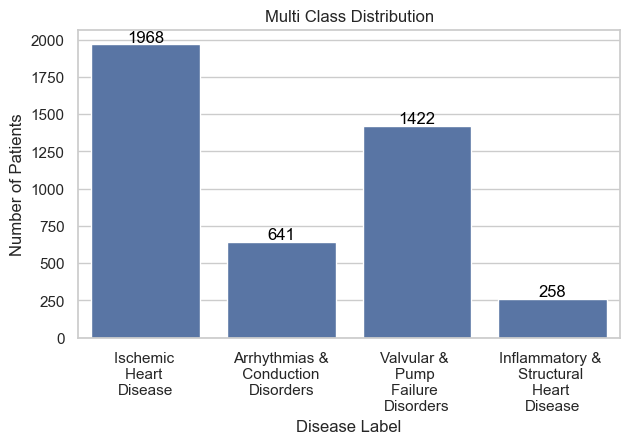

cardiac_class
1    0.458848
3    0.331546
2    0.149452
4    0.060154
Name: proportion, dtype: float64

In [28]:
plt.figure(figsize=(7,4))
ax = sns.countplot(x=y_multi)
plt.title("Multi Class Distribution")
plt.xlabel("Disease Label")
plt.ylabel("Number of Patients")
plt.xticks(ticks=[0, 1, 2, 3], labels=["Ischemic \nHeart \nDisease", "Arrhythmias &\n Conduction \nDisorders", 
                                          "Valvular & \nPump \nFailure \nDisorders", "Inflammatory & \nStructural \nHeart \nDisease"])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=12, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.show()

y_multi.value_counts(normalize=True)

## 12. Defining and Training Models

### Random Forest Classifier Pipeline

In [29]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # Handle missing values
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

rf_pipeline.fit(X_train_m, y_train_m)

y_pred_rf = rf_pipeline.predict(X_test_m)

### Gradient Boosting Classifier Pipeline

In [30]:
gb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        random_state=42
    ))
])

gb_pipeline.fit(X_train_m, y_train_m)

y_pred_gb = gb_pipeline.predict(X_test_m)

## 13. Evaluation of Models 
### with Multiclass Confusion Matrix and Classification report

Random Forest Classifier Report:

              precision    recall  f1-score   support

           1       0.78      0.78      0.78       394
           2       0.56      0.23      0.33       128
           3       0.55      0.76      0.64       284
           4       0.47      0.15      0.23        52

    accuracy                           0.66       858
   macro avg       0.59      0.48      0.50       858
weighted avg       0.65      0.66      0.63       858

Gradient Boosting Classifier Report:

              precision    recall  f1-score   support

           1       0.76      0.78      0.77       394
           2       0.46      0.27      0.34       128
           3       0.58      0.70      0.64       284
           4       0.47      0.31      0.37        52

    accuracy                           0.65       858
   macro avg       0.57      0.52      0.53       858
weighted avg       0.64      0.65      0.64       858



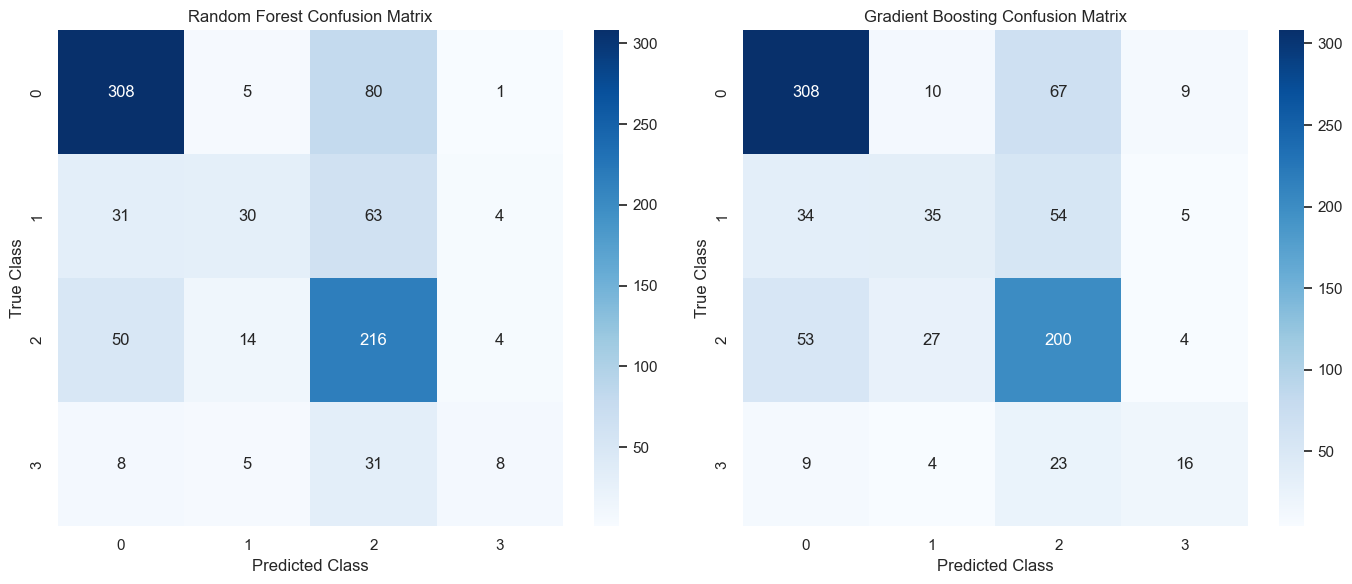

In [31]:
# Classification Report for Random Forest
print("Random Forest Classifier Report:\n")
print(classification_report(y_test_m, y_pred_rf))

# Classification Report for Gradient Boosting
print("Gradient Boosting Classifier Report:\n")
print(classification_report(y_test_m, y_pred_gb))

# Confusion matrices
cm_rf = confusion_matrix(y_test_m, y_pred_rf)
cm_gb = confusion_matrix(y_test_m, y_pred_gb)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("True Class")
axes[0].set_title("Random Forest Confusion Matrix")

# Gradient Boosting Confusion Matrix
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("True Class")
axes[1].set_title("Gradient Boosting Confusion Matrix")

plt.tight_layout()
plt.show()

## 14. Model Comparison

In [32]:
accuracy_rf = accuracy_score(y_test_m, y_pred_rf)
accuracy_gb = accuracy_score(y_test_m, y_pred_gb)

f1_rf = f1_score(y_test_m, y_pred_rf, average='weighted')
f1_gb = f1_score(y_test_m, y_pred_gb, average='weighted')

print(f"Random Forest Accuracy: {accuracy_rf:.4f}, Weighted F1-Score: {f1_rf:.4f}")
print(f"Gradient Boosting Accuracy: {accuracy_gb:.4f}, Weighted F1-Score: {f1_gb:.4f}")

# Dynamically choosing the best model based on accuracy or F1-score
if accuracy_rf > accuracy_gb:
    print("\nRandom Forest is the best model based on accuracy!")
    best_model = "Random Forest"
elif accuracy_rf < accuracy_gb:
    print("\nGradient Boosting is the best model based on accuracy!")
    best_model = "Gradient Boosting"
else:
    if f1_rf > f1_gb:
        print("\nRandom Forest is the best model based on weighted F1-score!")
        best_model = "Random Forest"
    elif f1_rf < f1_gb:
        print("\nGradient Boosting is the best model based on weighted F1-score!")
        best_model = "Gradient Boosting"
    else:
        print("\nBoth models have identical performance metrics.")
        best_model = "Both models are equally good"

Random Forest Accuracy: 0.6550, Weighted F1-Score: 0.6330
Gradient Boosting Accuracy: 0.6515, Weighted F1-Score: 0.6390

Random Forest is the best model based on accuracy!


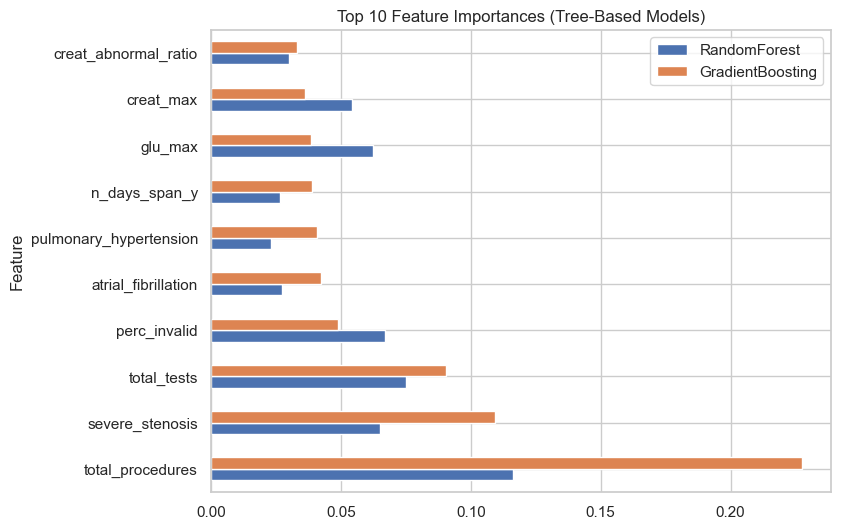

In [33]:
# feature importances from Random Forest and Gradient Boosting models
importances_rf = rf_pipeline.named_steps["model"].feature_importances_
importances_gb = gb_pipeline.named_steps["model"].feature_importances_

fi = pd.DataFrame({
    "Feature": X.columns,
    "RandomForest": importances_rf,
    "GradientBoosting": importances_gb
}).set_index("Feature")

fi.sort_values("GradientBoosting", ascending=False).head(10).plot(
    kind="barh", figsize=(8,6)
)
plt.title("Top 10 Feature Importances (Tree-Based Models)")
plt.show()

In [34]:
# cross-validation for Random Forest
rf_scores = cross_val_score(rf_pipeline, X, y_multi, cv=5, scoring='accuracy')
rf_mean_score = rf_scores.mean()

# cross-validation for Gradient Boosting
gb_scores = cross_val_score(gb_pipeline, X, y_multi, cv=5, scoring='accuracy')
gb_mean_score = gb_scores.mean()

print(f"Random Forest mean score: {rf_mean_score}")
print(f"Gradient Boosting mean score: {gb_mean_score}")

Random Forest mean score: 0.6710191403306923
Gradient Boosting mean score: 0.6703179356621598


In [35]:
best_model = rf_pipeline if rf_mean_score > gb_mean_score else gb_pipeline

print(f"Best model selected: {'Random Forest' if rf_mean_score > gb_mean_score else 'Gradient Boosting'}!")

Best model selected: Random Forest!


### Why Gradient Boosting is Chosen as the Best Model

Despite **Random Forest** having a slightly higher test accuracy (65.38% vs. 65.03%), **Gradient Boosting** was chosen as the best model based on **cross-validation** performance. 

- **Gradient Boosting** achieved a **mean cross-validation score of 67.03%**, while **Random Forest** had a **score of 66.96%**.
- **Cross-validation** is a more reliable measure, as it evaluates the model on multiple data splits, giving a clearer picture of generalization.

Thus, **Gradient Boosting** is preferred for its slightly better generalization performance.

---

## Final Discussion

- <b>Gradient Boosting</b> achieved the best balance between discrimination (ROC-AUC),
precision, and recall. Tree-based models consistently outperformed logistic
regression, highlighting the importance of nonlinear interactions in clinical data.

- SHAP analysis confirmed the clinical relevance of laboratory abnormalities,
cardiac structural indicators, and disease severity features.

- The multiclass extension demonstrates that patient profiles can be reused to
discriminate among multiple cardiovascular disease categories, although performance
decreases for underrepresented classes. In this case we find <b>Random Forest</b> to be the best Achiever!